In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("zillow_final.csv")
df.head(5)

,price,bed,bath,living,lot_sqft,lot_living,bed_bath,type_condo,type_manufactured,type_multi,...,risk_overall,risk_loss,risk_social,risk_resilience,risk_fire,risk_earthquake,risk_heat,dist_city,dist_airport,dist_coast
0,4980000.0,4.0,5.0,4126.0,4922.000,1.192923,0.8,False,False,False,...,80.718966,89.710407,9.209856,12.692809,73.920540,94.138632,8.354783,13.715619,17.888756,13.623171
1,1215000.0,3.0,2.0,1825.0,7840.800,4.296329,1.5,False,False,False,...,75.714982,83.604998,23.062252,12.692809,18.467649,89.615069,13.904381,39.379252,34.192540,22.666476
2,2629000.0,4.0,4.0,3019.0,43381.404,14.369461,1.0,False,False,False,...,92.322785,96.534514,9.209856,12.692809,98.160370,93.614213,13.158396,18.768005,19.185657,11.646300
3,400000.0,3.0,2.0,944.0,4268.880,4.522119,1.5,False,False,True,...,68.423055,43.952134,93.082983,12.692809,0.000000,93.975717,20.717146,9.473542,11.193127,18.586372
4,849000.0,2.0,2.0,1154.0,5002.000,4.334489,1.0,False,False,False,...,53.028195,54.870000,40.578096,12.692809,0.000000,87.909814,8.907717,37.911992,27.545766,35.124601


In [4]:
upper = df["price"].quantile(0.95)
df = df[df["price"] <= upper]

In [5]:
print(df.info())


<class 'pandas.DataFrame'>
Index: 4251 entries, 0 to 4467
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price              4251 non-null   float64
 1   bed                4251 non-null   float64
 2   bath               4251 non-null   float64
 3   living             4251 non-null   float64
 4   lot_sqft           4251 non-null   float64
 5   lot_living         4251 non-null   float64
 6   bed_bath           4251 non-null   float64
 7   type_condo         4251 non-null   bool   
 8   type_manufactured  4251 non-null   bool   
 9   type_multi         4251 non-null   bool   
 10  type_single        4251 non-null   bool   
 11  type_townhouse     4251 non-null   bool   
 12  lat                4251 non-null   float64
 13  long               4251 non-null   float64
 14  income             4251 non-null   float64
 15  poverty            4251 non-null   float64
 16  unemployment       4251 non-null   float

DATA PREPROCESSING

In [6]:
X = df.drop(columns = ["price"])

y = df["price"]


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)

(3400, 32)


In [8]:
print(X_train.shape)
print(X_test.shape)

(3400, 32)
(851, 32)


#MÔ HÌNH 1: LINEAR REGRESSION

In [9]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
y_pred_lr = lr.predict(X_test)

In [11]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = root_mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MAE =", mae)
print("RMSE =", rmse)
print("R2 =", r2)

Linear Regression
MAE = 525920.2484214175
RMSE = 890610.5697283492
R2 = 0.710276288972899


In [12]:
# Mô hình 2 : Random Forest

In [13]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [14]:
y_pred_rf = rf.predict(X_test)

In [15]:
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = root_mean_squared_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("MAE =", mae)
print("RMSE =", rmse)
print("R2 =", r2)

Random Forest
MAE = 354814.80758275924
RMSE = 715849.1455797134
R2 = 0.812823478865236


# Mô hình 3: XGBosst

In [16]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [17]:
y_pred_xgb = xgb.predict(X_test)

In [18]:
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = root_mean_squared_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost")
print("MAE =", mae)
print("RMSE =", rmse)
print("R2 =", r2)

XGBoost
MAE = 333347.66235552385
RMSE = 672936.923446881
R2 = 0.834591788439265


In [24]:
import matplotlib.pyplot as plt

comparison = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "MAE": mean_absolute_error(y_test, y_pred_lr),
        "RMSE": root_mean_squared_error(y_test, y_pred_lr),
        "R2": r2_score(y_test, y_pred_lr),
    },
    {
        "Model": "Random Forest",
        "MAE": mean_absolute_error(y_test, y_pred_rf),
        "RMSE": root_mean_squared_error(y_test, y_pred_rf),
        "R2": r2_score(y_test, y_pred_rf),
    },
    {
        "Model": "XGBoost",
        "MAE": mean_absolute_error(y_test, y_pred_xgb),
        "RMSE": root_mean_squared_error(y_test, y_pred_xgb),
        "R2": r2_score(y_test, y_pred_xgb),
    },
]).set_index("Model")

print(comparison)



                             MAE           RMSE        R2
Model                                                    
Linear Regression  525920.248421  890610.569728  0.710276
Random Forest      354814.807583  715849.145580  0.812823
XGBoost            333347.662356  672936.923447  0.834592


LỰA CHỌN MÔ HÌNH XGBoost ĐỂ TỐI ƯU VÌ NÓ TỐT NHẤT 

Feature Importances

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance.head(15))

            Feature  Importance
19  area_home_value    0.457374
2            living    0.084442
1              bath    0.053731
9       type_single    0.034294
27  risk_earthquake    0.033527
28        risk_heat    0.029518
8        type_multi    0.027096
31       dist_coast    0.023270
22     risk_overall    0.020512
16              pop    0.020142
21      pop_density    0.015681
5          bed_bath    0.014071
25  risk_resilience    0.014067
14          poverty    0.012876
26        risk_fire    0.012411


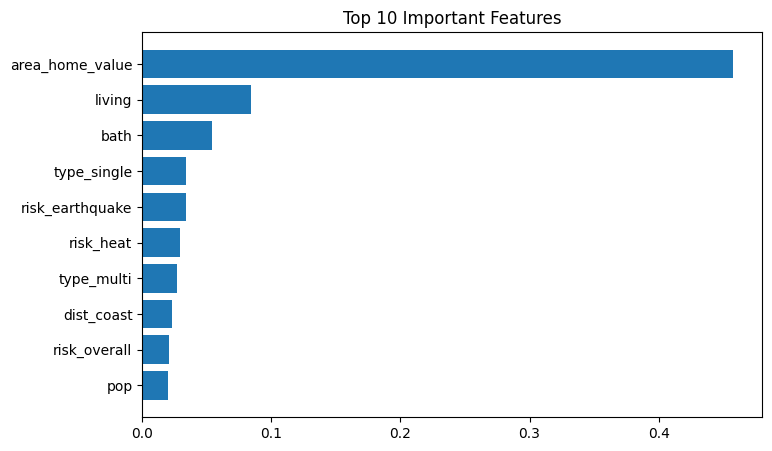

In [ ]:
import matplotlib.pyplot as plt

top = importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(top["Feature"], top["Importance"])

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.show()

Kết luận cho phần Feature Importance

Các biến có độ quan trọng cao nhất phản ánh những yếu tố ảnh hưởng trực tiếp đến giá nhà như vị trí, diện tích và các đặc điểm tiện ích. Điều này cho thấy mô hình XGBoost đang học được những tín hiệu phù hợp với thực tế thị trường bất động sản và có thể dùng để giải thích vì sao một bất động sản được định giá cao hoặc thấp.

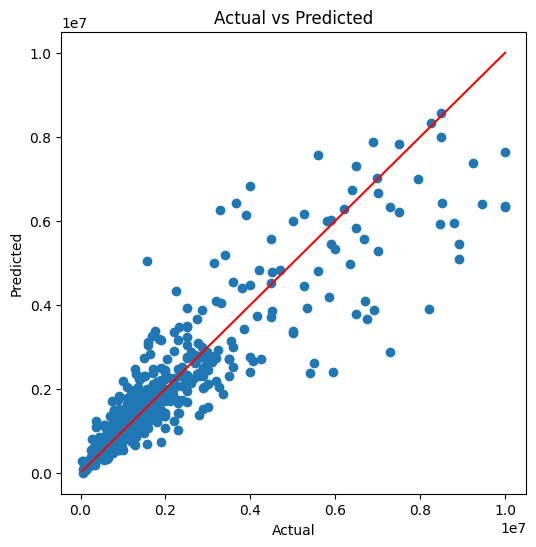

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_xgb)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

Kết luận cho phần Actual vs Predicted

Đường thẳng đỏ thể hiện mức dự đoán hoàn hảo. Nếu các điểm phân tán gần đường này, mô hình dự đoán khá chính xác; nếu điểm phân tán xa, mô hình còn có sai số. Với kết quả này, mô hình XGBoost cho thấy khả năng dự đoán tốt, nhưng vẫn tồn tại một số sai lệch ở các giá trị cực đoan, điều này là khá bình thường trong bài toán định giá bất động sản.